In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.utils import resample
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import os



In [2]:
#Loading the dataset
# df = pd.read_pickle("dataframes\\final_df.pkl")
# df_union = pd.read_pickle("dataframes\\final_df_union.pkl")
# print(len(df))
# print(len(df_union))

df_union = pd.read_pickle("dataframes\\final_df_union.pkl")
df_majority = pd.read_pickle("dataframes\\final_df_maj.pkl")

In [4]:
display(df[(df['video_id'] == "vid3_seg5") & (df['agent_id'] == 14) & (df['frame_id'] == 1)])
display(df_union[(df_union['video_id'] == "vid3_seg5") & (df_union['agent_id'] == 14) & (df_union['frame_id'] == 1)])
print(len(df))
print(len(df_union))

,video_id,camera_id,frame_id,agent_id,num_kp,keypoints,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio
2894924,vid3_seg5,cam6,1,14,17,"[[0.08274128581355314, 0.573485618174173], [0....","[0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, ...",0.0,0.0,NaN


,video_id,camera_id,frame_id,agent_id,num_kp,keypoints,occluded,is_laughing_no_audio,is_laughing_only_audio,is_laughing_with_audio
2894924,vid3_seg5,cam6,1,14,17,"[[0.08274128581355314, 0.573485618174173], [0....","[0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, ...",0,0,NaN


3926964
3926964


In [3]:
#df = df[~((df['video_id'] == "vid3_seg5") & (df['agent_id'] == 14))]
df_union = df_union[~((df_union['video_id'] == "vid3_seg5") & (df_union['agent_id'] == 14))]
df_majority = df_majority[~((df_majority['video_id'] == "vid3_seg5") & (df_majority['agent_id'] == 14))]

# print(len(df))
print(len(df_union))

3919767


In [4]:
def cam_points(df):
    """
    Filters the DataFrame to retain only the camera view with the highest total keypoint visibility
    (i.e., sum of `num_kp`) for each (video_id, agent_id) pair.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame that must include columns:
        ['video_id', 'agent_id', 'camera_id', 'num_kp']

    Returns:
    --------
    pd.DataFrame
        Filtered DataFrame containing only rows from the most informative camera
        per agent per video.
    """
    # Compute total visible keypoints per (video, agent, camera)
    camera_kp_totals = (
        df.groupby(['video_id', 'agent_id', 'camera_id'])['num_kp']
        .sum()
        .reset_index()
    )

    # Debug: Inspect a specific agent-video combination
    display(camera_kp_totals[
        (camera_kp_totals['video_id'] == "vid3_seg5") &
        (camera_kp_totals['agent_id'] == 2)
    ])

    # For each (video_id, agent_id), select the camera with the highest total keypoints
    camera_kp_totals = camera_kp_totals.loc[
        camera_kp_totals.groupby(['video_id', 'agent_id'])['num_kp'].idxmax()
    ]

    # Keep only the top-camera rows in the original DataFrame
    key_columns = ['video_id', 'agent_id', 'camera_id']
    return df.merge(camera_kp_totals[key_columns], on=key_columns, how='inner')


,video_id,agent_id,camera_id,num_kp
416,vid3_seg5,2,cam6,122343
417,vid3_seg5,2,cam8,143900


,video_id,agent_id,camera_id,num_kp
416,vid3_seg5,2,cam6,122343
417,vid3_seg5,2,cam8,143900


2278448


In [5]:
# df['keypoints'] = df['keypoints'].apply(lambda x: np.array(x))
# df['occluded'] = df['occluded'].apply(lambda x: np.array(x))
df_union['keypoints'] = df_union['keypoints'].apply(lambda x: np.array(x))
df_union['occluded'] = df_union['occluded'].apply(lambda x: np.array(x))
df_majority['keypoints'] = df_majority['keypoints'].apply(lambda x: np.array(x))
df_majority['occluded'] = df_majority['occluded'].apply(lambda x: np.array(x))
# print(df.columns)
# display(df)


In [6]:
def plot_agent_segments_heatmap(s, big_df, modality):
    """
    Generates and saves a heatmap visualization of agent segments and annotations for a given modality.

    Parameters:
    -----------
    s : list or pd.DataFrame
        List of segment dictionaries or a DataFrame with the following required columns:
        ['video_id', 'agent_id', 'start_frame', 'end_frame', 'label'].
        Each row represents a labeled segment for an agent.

    big_df : pd.DataFrame
        DataFrame containing full frame-level annotations, including:
        ['video_id', 'agent_id', 'frame_id', <modality>].

    modality : str
        The name of the column in `big_df` that contains the annotation values to visualize
        (e.g., "no_audio", "audio_only", etc.).

    Returns:
    --------
    str
        Path to the directory where the heatmap image(s) were saved.
    """
    df = pd.DataFrame(s)  # Ensure input is a DataFrame
    output_dir = "segment_plots"  # Directory to save plots

    for video_id in df['video_id'].unique():  # Iterate over unique videos
        video_df = df[df['video_id'] == video_id]  # Segments for current video
        big_video_df = big_df[big_df['video_id'] == video_id]  # Full annotations for current video
        max_frame = big_video_df['frame_id'].max()  # Determine max frame index
        agent_ids = sorted(big_video_df['agent_id'].unique())  # Get all unique agent IDs
        n_rows = 3 * (max(agent_ids) + 1)  # Each agent gets 3 rows (neg, pos, actual annotation)

        # Initialize empty grid for heatmap
        grid = np.zeros((n_rows, max_frame + 1))

        display(video_df.iloc[-1])  # Display last segment row for debugging

        # Fill grid for positive and negative segment labels
        for _, row in video_df.iterrows():
            y = 3 * int(row['agent_id']) + int(row['label'])  # 0 for neg, 1 for pos
            grid[y, int(row['start_frame']):int(row['end_frame']) + 1] += 1  # Mark segment frames

        # Fill grid with actual per-frame annotations (offset 2 for each agent)
        for _, row in big_video_df.iterrows():
            y = 3 * row['agent_id'] + 2  # Third row for agent contains continuous annotation
            grid[y, int(row['frame_id'])] += (row[modality] + 1)  # Offset to avoid zero value

        # Define color map (black to red)
        cmap = LinearSegmentedColormap.from_list("black_red", ["#000000", "#FF0000"])

        # Create heatmap plot
        plt.figure(figsize=(20, max(6, len(agent_ids))))  # Set figure size dynamically
        ax = sns.heatmap(grid, cmap=cmap, cbar=True)
        ax.set_title(f"Segment Heatmap for Video {video_id}", fontsize=14)
        ax.set_xlabel("Frame")
        ax.set_ylabel("2 * agent_id (+1 for positive)")

        # Set custom y-axis ticks and labels
        yticks = []
        ylabels = []
        for aid in agent_ids:
            yticks.extend([3 * aid, 3 * aid + 1, 3 * aid + 2])
            ylabels.extend([
                f"Agent {aid} (neg)",
                f"Agent {aid} (pos)",
                f"Agent {aid} actual annotation"
            ])
        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, rotation=0)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/video_{video_id}_segments_fixed.png")  # Save plot
        plt.show()
        plt.close()

        break  # Only process the first video

    return f"Saved heatmaps to {output_dir}"

In [7]:
def add_segment_fixed(segment, segments, video_id, agent_id, current_label, seg_lenght, ot):
    """
    Splits a continuous labeled segment into fixed-length sub-segments and appends them to the segments list
    if visibility criteria are met.

    Parameters:
    -----------
    segment : pd.DataFrame
        DataFrame slice containing pose frames for a single label window.

    segments : list
        List to store resulting segment dictionaries.

    video_id : int or str
        ID of the video the segment belongs to.

    agent_id : int
        ID of the agent the segment belongs to.

    current_label : int
        Label of the segment (1 for positive, 0 for negative).

    seg_lenght : int
        Fixed length of each segment to produce.

    ot : float
        Occlusion threshold — maximum allowed fraction of missing keypoints.
    """
    if len(segment) == 0: return

    segment = segment.sort_values(by=["frame_id"])  # Sort frames by time
    start_frame = segment['frame_id'].min()
    final_frame = segment['frame_id'].max()

    # Slide window across the segment, generating fixed-length windows
    while start_frame < final_frame:
        end_frame = start_frame + seg_lenght

        # Extract frames within the current window
        seg = segment[(segment['frame_id'] >= start_frame) & (segment['frame_id'] <= end_frame)]

        # Compute visible keypoints ratio
        total_kps = len(seg) * 17
        visible_kps = sum(seg["num_kp"])

        # Only keep segment if visibility threshold is met
        if visible_kps / total_kps >= (1 - ot):
            segments.append({
                'video_id': video_id,
                'agent_id': agent_id,
                'start_frame': start_frame,
                'end_frame': end_frame,
                'label': current_label,
                'length': end_frame - start_frame,
            })

        start_frame = end_frame + 1  # Move to next window


def pad_segment(start, end, min_frame, max_frame, seg_lenght, delay):
    """
    Pads or adjusts a segment so its length is a multiple of `seg_lenght`, ensuring it remains within valid bounds.

    Parameters:
    -----------
    start : int
        Starting frame of the segment (before padding).

    end : int
        Ending frame of the segment (before padding).

    min_frame : int
        Minimum valid frame index in the video.

    max_frame : int
        Maximum valid frame index in the video.

    seg_lenght : int
        Target fixed segment length.

    delay : int
        Padding shift applied to the start (typically to compensate for annotation delay).

    Returns:
    --------
    tuple
        (start_frame, end_frame) after padding. If not possible, returns (-1, -1).
    """
    start_frame = max(start - delay, min_frame)
    end_frame = end

    rem_frames = seg_lenght - ((end_frame - start_frame) % seg_lenght)

    # Case 1: Can't shift in either direction
    if start_frame - rem_frames // 2 < min_frame and end_frame + rem_frames // 2 > max_frame:
        if max_frame - min_frame < seg_lenght:
            return -1, -1  # Not enough space
        # Trim instead of pad
        frames_to_be_removed = (end_frame - start_frame) % seg_lenght
        start_frame += frames_to_be_removed // 2
        end_frame -= (frames_to_be_removed - frames_to_be_removed // 2)
        assert (end_frame - start_frame) % seg_lenght == 0

    # Case 2: Can only pad end
    elif start_frame - rem_frames // 2 < min_frame:
        end_frame += (rem_frames - start_frame)
        start_frame = min_frame

    # Case 3: Can only pad start
    elif end_frame + rem_frames // 2 > max_frame:
        start_frame += rem_frames - (max_frame - end_frame)
        end_frame = max_frame

    # Case 4: Can pad both sides
    else:
        add_beg = rem_frames // 2
        add_end = rem_frames - add_beg
        start_frame -= add_beg
        end_frame += add_end

    return start_frame, end_frame


def segment_same_window(data_frame, ann_column, occlusion_threshold, seg_lenght, delay):
    """
    Segments labeled motion data into fixed-length windows for both positive and negative cases,
    considering occlusion and annotation delay.

    Parameters:
    -----------
    data_frame : pd.DataFrame
        Frame-level data for multiple videos and agents. Must contain:
        ['video_id', 'agent_id', 'frame_id', 'num_kp', ann_column].

    ann_column : str
        Column name for binary annotation labels (1 = positive, 0 = negative).

    occlusion_threshold : float
        Maximum allowed proportion of occluded keypoints (0 = fully visible, 1 = fully occluded).

    seg_lenght : int
        Target segment length (e.g., 60 frames).

    delay : int
        Number of frames to shift the window start backward (to anticipate annotation delay).

    Returns:
    --------
    list
        List of fixed-length segment dictionaries with metadata.
    """
    segments = []

    MIN_NEGATIVE_GAP = seg_lenght  # Minimum margin inside negative segments
    MIN_THRESHOLD = 20  # Ignore very short positive spans
    SEGMENT_LEN = seg_lenght
    DELAY = delay

    # Iterate through each (video, agent) pair
    for (video_id, agent_id), group in data_frame.groupby(['video_id', 'agent_id']):
        group = group.reset_index(drop=True)

        min_frame = group['frame_id'].min()
        max_frame = group['frame_id'].max()

        ranges = []

        # ---- Positive segments ----
        positive_group = group[group[ann_column] == 1].sort_values(by=['frame_id'])
        start = -1
        end = -1

        for i, row in positive_group.iterrows():
            if start == -1:
                start = row['frame_id']
            elif row['frame_id'] > (end + 1):
                # Gap detected; finalize previous segment
                if end - start >= MIN_THRESHOLD:
                    s, e = pad_segment(start, end, min_frame, max_frame, SEGMENT_LEN, DELAY)
                    ranges.append((s, e))
                    add_segment_fixed(group[s : (e + 1)], segments, video_id, agent_id, 1, SEGMENT_LEN, occlusion_threshold)
                start = -1
            end = row['frame_id']

        # Final trailing segment
        if start != -1 and end != -1:
            s, e = pad_segment(start, end, min_frame, max_frame, SEGMENT_LEN, DELAY)
            if s != -1:
                add_segment_fixed(group[s : (e + 1)], segments, video_id, agent_id, 1, SEGMENT_LEN, occlusion_threshold)

        # ---- Negative segments ----
        negative_group = group[group[ann_column] == 0].sort_values(by=['frame_id'])
        start = -1
        end = -1

        for i, row in negative_group.iterrows():
            if start == -1:
                start = row['frame_id']
            elif row['frame_id'] > (end + 1):
                # Margin offset inside segment
                start = start + MIN_NEGATIVE_GAP
                end = end - MIN_NEGATIVE_GAP

                if end > start + seg_lenght:
                    s, e = pad_segment(start, end, start, end, SEGMENT_LEN, DELAY)
                    ranges.append((s, e))
                    add_segment_fixed(group[s : (e + 1)], segments, video_id, agent_id, 0, SEGMENT_LEN, occlusion_threshold)
                start = -1
            end = row['frame_id']

        # Final trailing negative segment
        if start != -1 and end != -1 and end > start + MIN_NEGATIVE_GAP + seg_lenght:
            s, e = pad_segment(start + MIN_NEGATIVE_GAP, end - MIN_NEGATIVE_GAP,
                               start + MIN_NEGATIVE_GAP, end - MIN_NEGATIVE_GAP,
                               SEGMENT_LEN, DELAY)
            ranges.append((s, e))
            add_segment_fixed(group[s : (e + 1)], segments, video_id, agent_id, 0, SEGMENT_LEN, occlusion_threshold)

    return segments



In [51]:
def plot_segment_heatmap_two(s, big_df, modality):
    """
    Generates a detailed heatmap visualization for a selected frame range and subset of agents (1–3),
    comparing predicted segment labels with actual annotations for a given video.

    Parameters:
    -----------
    s : list or pd.DataFrame
        List of dictionaries or DataFrame containing segment predictions. Must have:
        ['video_id', 'agent_id', 'start_frame', 'end_frame', 'label'].

    big_df : pd.DataFrame
        Full frame-level annotation data. Must contain:
        ['video_id', 'agent_id', 'frame_id', <modality>] where <modality> is a binary column.

    modality : str
        Name of the column in `big_df` to use for actual annotations (e.g., "audio_only").

    Returns:
    --------
    str
        Message indicating the directory where the heatmap image was saved.
    """
    df = pd.DataFrame(s)  # Ensure input is a DataFrame
    output_dir = "segment_plots"
    os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

    # Hardcoded focus: only agents 1–3 and a specific frame window
    agent_filter = [1, 2, 3]
    frame_start = 2650
    frame_end = 5300

    for video_id in df['video_id'].unique():  # Process the first unique video
        video_df = df[df['video_id'] == video_id]
        big_video_df = big_df[big_df['video_id'] == video_id]

        # Filter by agent and frame window
        video_df = video_df[video_df['agent_id'].isin(agent_filter)]
        big_video_df = big_video_df[big_video_df['agent_id'].isin(agent_filter)]
        video_df = video_df[(video_df['end_frame'] >= frame_start) & (video_df['start_frame'] <= frame_end)]
        big_video_df = big_video_df[(big_video_df['frame_id'] >= frame_start) & (big_video_df['frame_id'] <= frame_end)]

        agent_ids = sorted(video_df['agent_id'].unique())
        n_rows = 3 * len(agent_ids)  # Each agent gets 3 rows: neg, pos, actual
        total_frames = frame_end - frame_start + 1

        # Initialize the heatmap grid
        grid = np.zeros((n_rows, total_frames))

        # Fill predicted segments: label + 1 to match color index
        for _, row in video_df.iterrows():
            agent_index = agent_filter.index(row['agent_id'])
            y = 3 * agent_index + int(row['label'])  # y-row for label (neg=0, pos=1)
            start = max(int(row['start_frame']), frame_start) - frame_start
            end = min(int(row['end_frame']), frame_end) - frame_start + 1
            grid[y, start:end] = row['label'] + 1

        # Fill actual annotations: value 3 for annotation presence
        for _, row in big_video_df.iterrows():
            if row[modality] == 1:
                agent_index = agent_filter.index(row['agent_id'])
                y = 3 * agent_index + 2  # y-row for actual annotation
                x = int(row['frame_id']) - frame_start
                if 0 <= x < total_frames:
                    grid[y, x] = 3

        # Custom color map: bg (0), neg (1), pos (2), actual (3)
        colors = ['#000000', '#003f5c', '#2f4b7c', '#ffa600']
        cmap = ListedColormap(colors)
        bounds = [0, 0.5, 1.5, 2.5, 3.5]
        norm = BoundaryNorm(bounds, len(colors))

        # Plotting heatmap
        plt.figure(figsize=(20, max(6, len(agent_ids) * 0.6)))
        ax = sns.heatmap(grid, cmap=cmap, norm=norm, cbar=True, linewidths=0.0)

        ax.set_title(f"Segment Heatmap for Video {video_id} (Agents 1–3, Frames {frame_start}–{frame_end})", fontsize=14)
        ax.set_xlabel("Frame")
        ax.set_ylabel("Agent Segments")

        # Y-axis tick labels for each agent
        yticks = []
        ylabels = []
        for idx, aid in enumerate(agent_filter):
            base = 3 * idx
            yticks.extend([base + 0.5, base + 1.5, base + 2.5])  # center of each row
            ylabels.extend([
                f"Agent {aid} (neg)",
                f"Agent {aid} (pos)",
                f"Agent {aid} actual annotation"
            ])
        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, rotation=0, fontsize=8, va='center')

        # X-axis frame ticks
        xtick_locs = np.linspace(0, total_frames - 1, 10, dtype=int)
        xtick_labels = [str(frame_start + i) for i in xtick_locs]
        ax.set_xticks(xtick_locs)
        ax.set_xticklabels(xtick_labels, rotation=45)

        plt.tight_layout()
        plt.savefig(f"{output_dir}/video_{video_id}_agents1to3_f2650to5300.png")
        plt.show()
        plt.close()

        break  # Only process the first video

    return f"Saved filtered heatmap to {output_dir}"



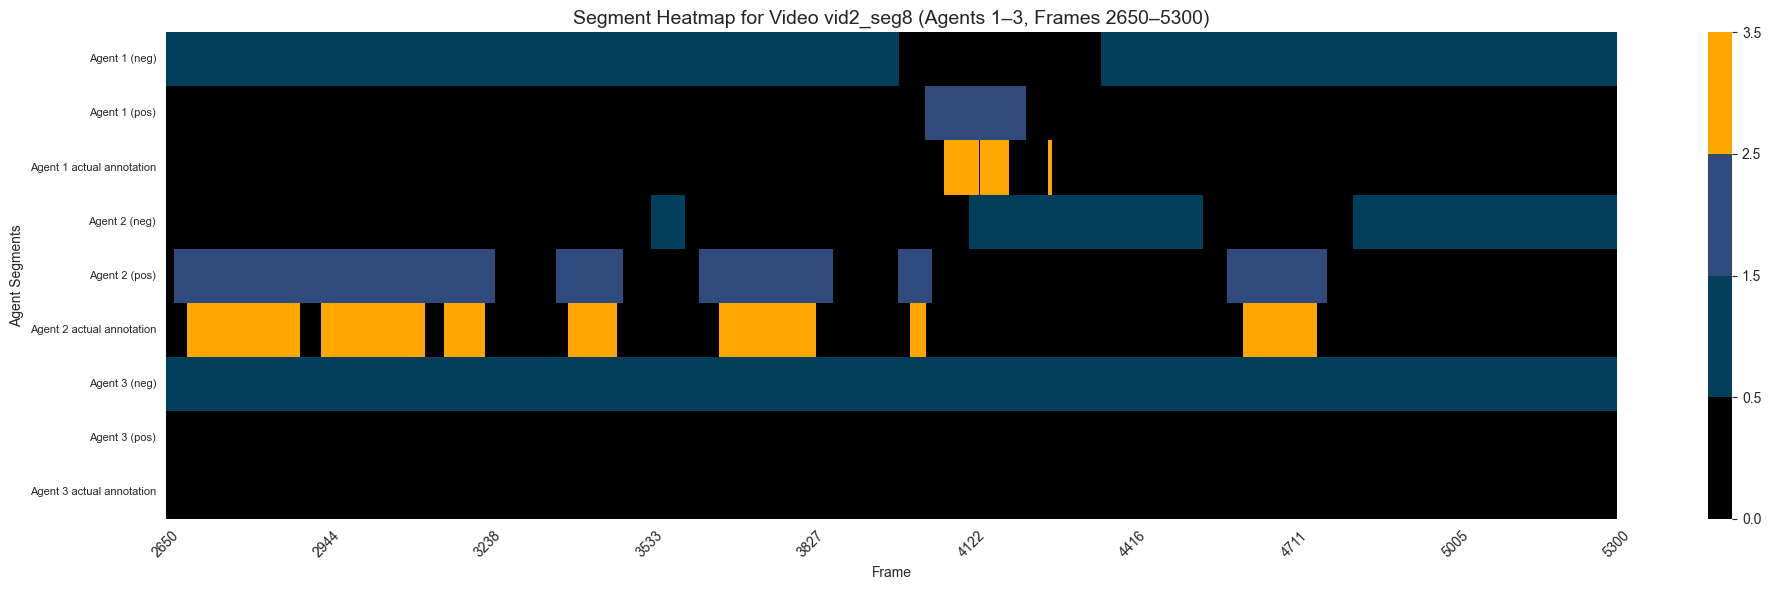

'Saved filtered heatmap to segment_plots'

In [53]:
sna_sixty_twelve = pd.DataFrame(segment_same_window(df_majority, "is_laughing_no_audio", 0.3, 60, 12))
plot_segment_heatmap_two(sna_sixty_twelve, df_majority, 'is_laughing_no_audio')


In [33]:
#Old variable length segmentation
def add_segment(visible_kps, total_kps, ot, segment, segments, segment_keypoints, video_id, agent_id, current_label, delay):
    """
    Adds a segment to the final list if the visibility condition is satisfied.
    Splits into randomized chunks if segment is too long.

    Parameters:
    -----------
    visible_kps : int
        Total number of visible keypoints in the segment.

    total_kps : int
        Total number of expected keypoints in the segment (frames × 17).

    ot : float
        Occlusion threshold (1 - max allowed visibility loss).

    segment : pd.DataFrame
        Frame-level data for the segment.

    segments : list
        Output list to store metadata of accepted segments.

    segment_keypoints : list
        Output list to store numpy arrays of segment keypoints.

    video_id : int or str
        ID of the video.

    agent_id : int
        ID of the agent.

    current_label : int
        Segment label (0 or 1).

    delay : int
        Frame shift applied to positive-labeled segments.
    """
    if visible_kps / total_kps >= (1 - ot):
        keypoints = np.stack(segment['keypoints'].values)  # Shape: (frames, 17, 2)
        n_frames = len(segment)
        max_len = 600
        min_len = 100

        # Case 1: Segment is already within length limits
        if n_frames <= max_len:
            # Adjust start for positive labels to account for delay
            start_frame = max(segment.iloc[0]['frame_id'] - delay, 0) if current_label == 1 else segment.iloc[0]['frame_id']
            n_frames = segment.iloc[-1]['frame_id'] - start_frame

            # Trim last positive segment to prevent overlap
            if current_label == 1:
                last_segment = segments[-1]
                if last_segment['video_id'] == video_id and last_segment['agent_id'] == agent_id:
                    last_segment['end_frame'] = start_frame - 1

            # Append full segment
            segments.append({
                'video_id': video_id,
                'agent_id': agent_id,
                'start_frame': start_frame,
                'end_frame': segment.iloc[-1]['frame_id'],
                'label': current_label,
                'length': n_frames
            })
            segment_keypoints.append(keypoints)

        # Case 2: Segment is too long — break into randomized chunks
        else:
            start = 0
            while start < n_frames:
                chunk_len = random.randint(min_len, max_len)  # Random chunk length
                end = min(start + chunk_len, n_frames)
                subseg = segment.iloc[start:end]
                keypoints_sub = np.stack(subseg['keypoints'].values)

                segments.append({
                    'video_id': video_id,
                    'agent_id': agent_id,
                    'start_frame': subseg.iloc[0]['frame_id'],
                    'end_frame': subseg.iloc[-1]['frame_id'],
                    'label': current_label,
                    'length': len(subseg)
                })
                segment_keypoints.append(keypoints_sub)

                start = end  # Advance to next chunk


def stop_episode(group, i, ann_column, current_label):
    """
    Determines whether a segmentation boundary should be placed at frame i.

    Parameters:
    -----------
    group : pd.DataFrame
        Frame-level data for one (video, agent) pair.

    i : int
        Index of the frame to check.

    ann_column : str
        Name of the annotation column.

    current_label : int
        Current label being tracked.

    Returns:
    --------
    bool
        True if the segment should be ended at index i.
    """
    # Default stop condition: label changes or temporal discontinuity
    default_stop = (
        group.loc[i, ann_column] != current_label or
        group.loc[i, 'frame_id'] - group.loc[i - 1, 'frame_id'] > 1
    )

    if not default_stop:
        return False

    # For label = 0 (negative), always stop
    if current_label == 0:
        return True

    # For label = 1 (positive), check if a continuation occurs soon after
    for j in range(30):  # Lookahead window
        if i + j >= len(group):
            break
        if group.loc[i + j, ann_column] == current_label:
            return False

    return True


def segment_var(data_frame, ann_column, occlusion_threshold, delay):
    """
    Segments agent trajectories into variable-length labeled windows based on annotation boundaries
    and occlusion thresholds.

    Parameters:
    -----------
    data_frame : pd.DataFrame
        Full dataset with frame-level annotations and keypoints.
        Required columns: ['video_id', 'agent_id', 'frame_id', 'num_kp', 'keypoints', ann_column].

    ann_column : str
        Column name containing binary annotations (0 or 1).

    occlusion_threshold : float
        Maximum allowable proportion of missing keypoints (0 = fully visible, 1 = fully missing).

    delay : int
        Number of frames to shift the start of a positive segment backward.

    Returns:
    --------
    list
        List of segmented dictionaries with metadata (start/end/label/etc.).
    """
    segments = []
    segment_keypoints = []

    # Process each (video, agent) group individually
    for (video_id, agent_id), group in data_frame.groupby(['video_id', 'agent_id']):
        group = group.reset_index(drop=True)
        current_label = group.loc[0, ann_column]
        start_idx = 0

        for i in range(1, len(group)):
            # If stop condition is met, finalize and add the current segment
            if stop_episode(group, i, ann_column, current_label):
                segment = group.iloc[start_idx:i]
                total_kps = len(segment) * 17
                visible_kps = sum(segment["num_kp"])
                add_segment(visible_kps, total_kps, occlusion_threshold, segment, segments,
                            segment_keypoints, video_id, agent_id, current_label, delay)

                # Reset for next segment
                start_idx = i
                current_label = group.loc[i, ann_column]

        # Handle final segment
        segment = group.iloc[start_idx:]
        total_kps = len(segment) * 17
        visible_kps = sum(segment["num_kp"])
        add_segment(visible_kps, total_kps, occlusion_threshold, segment, segments,
                    segment_keypoints, video_id, agent_id, current_label, delay)

    return segments


In [36]:
segna_var = segment_var(df_majority, "is_laughing_no_audio", 0.3, 12)
segwa_var = segment_var(df_majority, "is_laughing_with_audio", 0.3, 12)
segoa_var = segment_var(df_majority, "is_laughing_only_audio", 0.3, 12)


In [10]:
sna_three_twelve = segment_same_window(df_majority, "is_laughing_no_audio", 0.3, 180, 12)
swa_three_twelve = segment_same_window(df_majority, "is_laughing_with_audio", 0.3, 180, 12)
sao_three_twelve = segment_same_window(df_majority, "is_laughing_only_audio", 0.3, 180, 12)

sna_five_twelve = segment_same_window(df_majority, "is_laughing_no_audio", 0.3, 300, 12)
swa_five_twelve = segment_same_window(df_majority, "is_laughing_with_audio", 0.3, 300, 12)
sao_five_twelve = segment_same_window(df_majority, "is_laughing_only_audio", 0.3, 300, 12)

sna_ten_twelve = segment_same_window(df_majority, "is_laughing_no_audio", 0.3, 600, 12)
swa_ten_twelve = segment_same_window(df_majority, "is_laughing_with_audio", 0.3, 600, 12)
sao_ten_twelve = segment_same_window(df_majority, "is_laughing_only_audio", 0.3, 600, 12)

sna_one_twelve = segment_same_window(df_majority, "is_laughing_no_audio", 0.3, 60, 12)
swa_one_twelve = segment_same_window(df_majority, "is_laughing_with_audio", 0.3, 60, 12)
sao_one_twelve = segment_same_window(df_majority, "is_laughing_only_audio", 0.3, 60, 12)


1
2
3
4
5
6
7
8
9
10
11
12


In [38]:
def print_statistics(sd):
    sdf = pd.DataFrame(sd)


    # Summary statistics
    # print("\n--- Segment Length Stats ---")
    # print(sdf['length'].describe())

    laughter_segments = sdf[(sdf['label'] == 1)]
    non_laughter_segments = sdf[(sdf['label'] == 0)]
    mean_lenght_all = sdf['length'].mean()
    mean_laughter_segments = laughter_segments['length'].mean()
    mean_nonlaughter_segments = non_laughter_segments['length'].mean()

    print("\n--- Laughter Segment Length Stats ---")
    print(laughter_segments['length'].describe())


#     print("\n--- Segment Length Stats ---")
#     print(f"Mean of all: {mean_lenght_all}")
#     print(f"Mean of laughter: {mean_laughter_segments}")
#     print(f"Mean of nonlaughter: {mean_nonlaughter_segments}")
# # Plot histogram of segment lengths (laughing only) in red
#     plt.figure(figsize=(10, 5))
#     sns.histplot(laughter_segments['length'], bins=30, kde=True, color='red')
#     plt.title("Histogram of Laughing Segment Lengths < 1000 Frames")
#     plt.xlabel("Segment Length (frames)")
#     plt.ylabel("Frequency")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
#
#     # Plot histogram of segment lengths
#     plt.figure(figsize=(10, 5))
#     sns.histplot(sdf['length'], bins=30, kde=True)
#     plt.title("Histogram of Segment Lengths (in Frames)")
#     plt.xlabel("Segment Length (frames)")
#     plt.ylabel("Frequency")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
#
#     plt.figure(figsize=(10, 5))
#     short_segments = sdf[sdf['length'] < 1000]
#     sns.histplot(short_segments['length'], bins=30, kde=True)
#     plt.title("Histogram of Segment Lengths < 1000 Frames")
#     plt.xlabel("Segment Length (frames)")
#     plt.ylabel("Frequency")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
#
#     # Plot class distribution
#     plt.figure(figsize=(6, 4))
#     sns.countplot(x='label', data=sdf)
#     plt.title("Laughter vs Non-Laughter Segment Distribution")
#     plt.xlabel("Label (0 = No Laugh, 1 = Laugh)")
#     plt.ylabel("Segment Count")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
#
#     label_plot_data = sdf['label'].copy()
#     label_plot_data = label_plot_data.fillna("NaN")

    # plt.figure(figsize=(6, 4))
    # sns.countplot(x=label_plot_data)
    # plt.title("Laughter vs Non-Laughter Segment Distribution (Including NaNs)")
    # plt.xlabel("Label (0 = No Laugh, 1 = Laugh, NaN = Missing)")
    # plt.ylabel("Segment Count")
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

In [40]:
print_statistics(segna_var)
print_statistics(segwa_var)
print_statistics(segoa_var)



--- Laughter Segment Length Stats ---
count    578.000000
mean      81.432526
std       80.433939
min       12.000000
25%       34.000000
50%       55.000000
75%       96.000000
max      606.000000
Name: length, dtype: float64

--- Laughter Segment Length Stats ---
count    528.000000
mean      69.155303
std       71.047266
min       11.000000
25%       31.000000
50%       46.000000
75%       78.000000
max      550.000000
Name: length, dtype: float64

--- Laughter Segment Length Stats ---
count    628.000000
mean      58.361465
std       47.037685
min       12.000000
25%       28.000000
50%       45.000000
75%       71.000000
max      429.000000
Name: length, dtype: float64


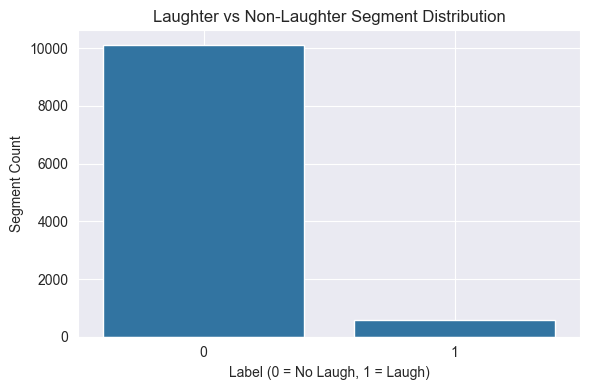

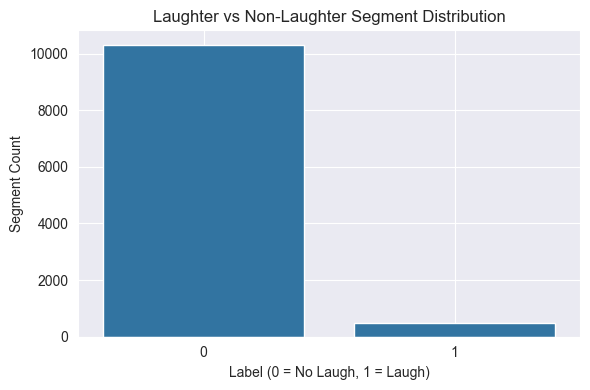

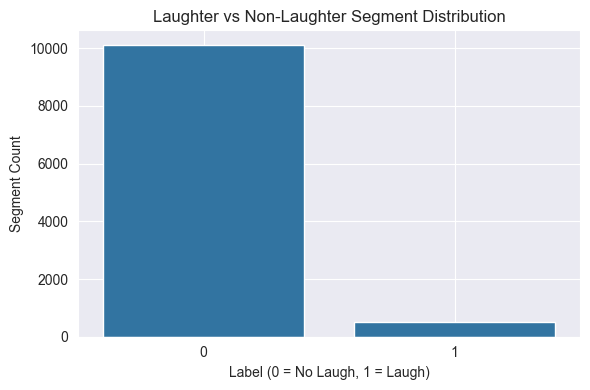

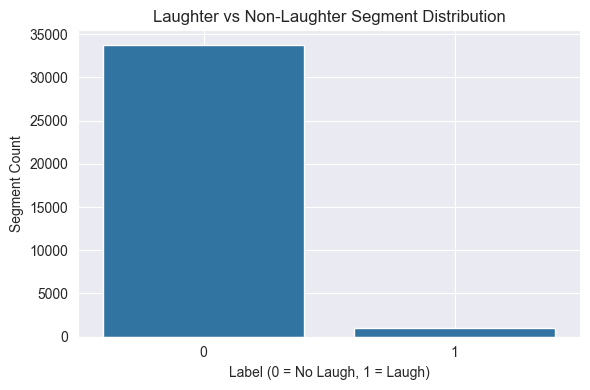

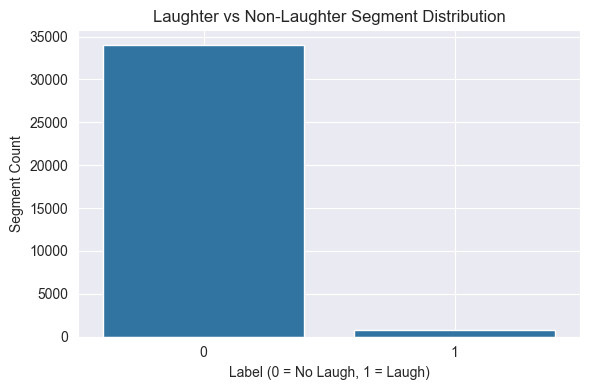

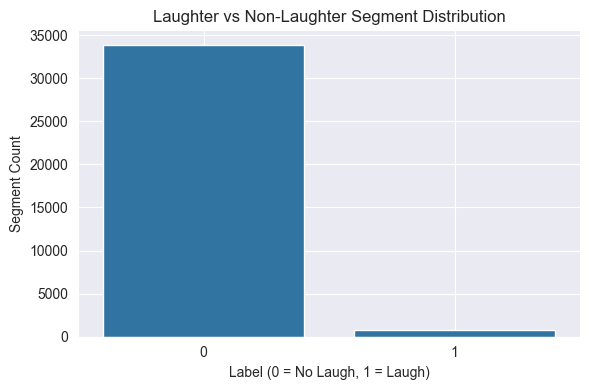

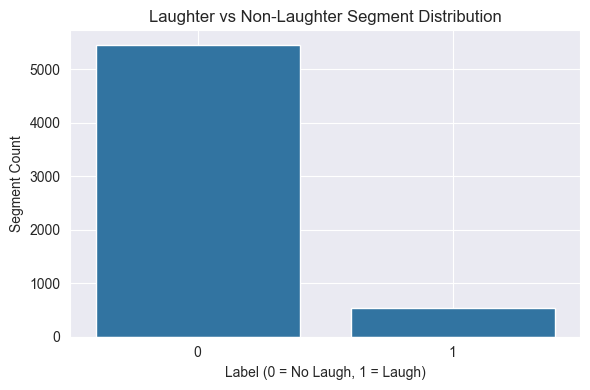

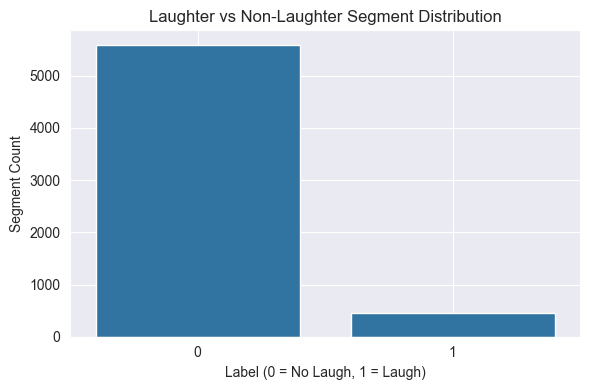

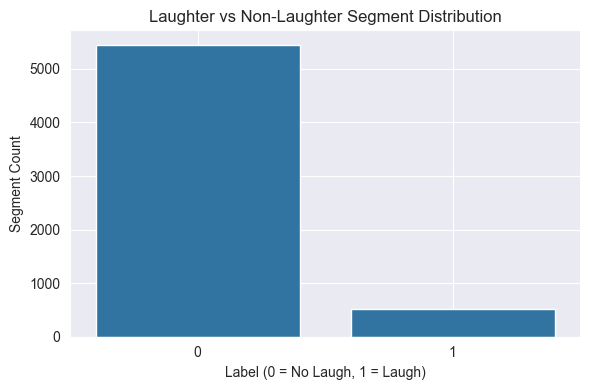

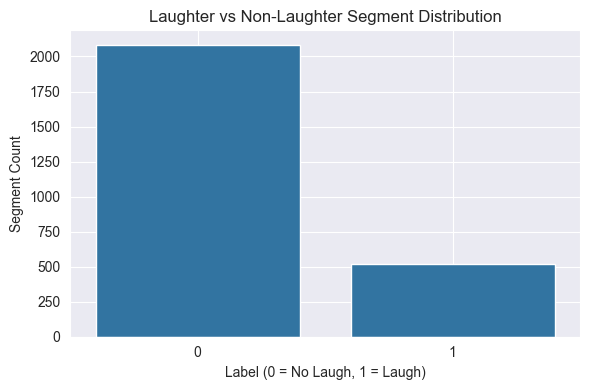

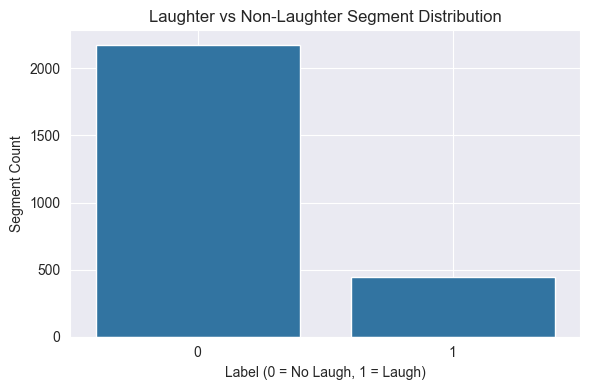

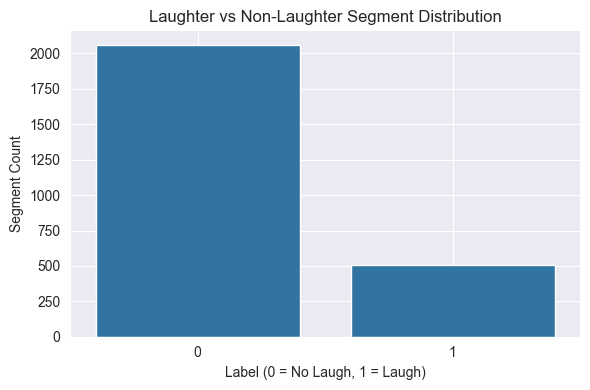

In [13]:
print_statistics(sna_three_twelve  )
print_statistics(swa_three_twelve  )
print_statistics(sao_three_twelve  )

print_statistics(sna_one_twelve)
print_statistics(swa_one_twelve)
print_statistics(sao_one_twelve)

print_statistics(sna_five_twelve)
print_statistics(swa_five_twelve)
print_statistics(sao_five_twelve)

print_statistics(sna_ten_twelve)
print_statistics(swa_ten_twelve)
print_statistics(sao_ten_twelve)


In [122]:
print(pd.DataFrame(sao_thirty_twelve_overlapping).columns)

Index(['video_id', 'agent_id', 'start_frame', 'end_frame', 'label', 'length'], dtype='object')


In [15]:
def remove_excess_segments(segments, ratio):
    """
    Balances segment labels per agent by downsampling negative segments to achieve a target laugh/no-laugh ratio.

    Parameters:
    -----------
    segments : list of dict
        List of segment dictionaries with keys including:
        ['agent_id', 'label', ...]. Typically produced by a segmentation function.

    ratio : float
        Desired ratio of positive (laugh) segments in the final dataset.
        For example, ratio=0.4 means 40% laugh, 60% no-laugh.

    Returns:
    --------
    pd.DataFrame
        DataFrame containing balanced segments per agent with approximately the specified ratio.
    """
    df_segments = pd.DataFrame(segments)
    balanced_segments = []

    # Process each agent's segments separately
    for agent_id, group in df_segments.groupby('agent_id'):
        laughs = group[group['label'] == 1]       # Positive class
        no_laughs = group[group['label'] == 0]    # Negative class

        num_laughs = len(laughs)

        # Determine how many no-laughs are needed to achieve the desired ratio
        desired_no_laughs = int(((1 - ratio) / ratio) * num_laughs)
        if desired_no_laughs == 0:
            desired_no_laughs = int((1 - ratio) * 100)  # fallback minimum

        if len(no_laughs) == 0:
            # No negative samples to balance; include only positives
            balanced_segments.append(laughs)
            continue

        # Downsample negative class to balance
        sampled_no_laughs = resample(
            no_laughs,
            replace=False,
            n_samples=min(len(no_laughs), desired_no_laughs),
            random_state=42
        )

        # Combine balanced groups
        balanced_group = pd.concat([laughs, sampled_no_laughs])
        balanced_segments.append(balanced_group)

    # Combine all agents' balanced groups into one DataFrame
    df_balanced = pd.concat(balanced_segments).reset_index(drop=True)
    return df_balanced


In [16]:
sna_one_twelve  = remove_excess_segments(sna_three_twelve,0.5)
swa_one_twelve  = remove_excess_segments(swa_three_twelve,0.5)
sao_one_twelve  = remove_excess_segments(sao_three_twelve,0.5)

sna_three_twelve  = remove_excess_segments(sna_three_twelve,0.5)
swa_three_twelve  = remove_excess_segments(swa_three_twelve,0.5)
sao_three_twelve  = remove_excess_segments(sao_three_twelve,0.5)

sna_five_twelve   = remove_excess_segments(sna_five_twelve,0.5)
swa_five_twelve   = remove_excess_segments(swa_five_twelve,0.5)
sao_five_twelve   = remove_excess_segments(sao_five_twelve,0.5)

sna_ten_twelve    = remove_excess_segments(sna_ten_twelve,0.5)
swa_ten_twelve    = remove_excess_segments(swa_ten_twelve,0.5)
sao_ten_twelve    = remove_excess_segments(sao_ten_twelve,0.5)

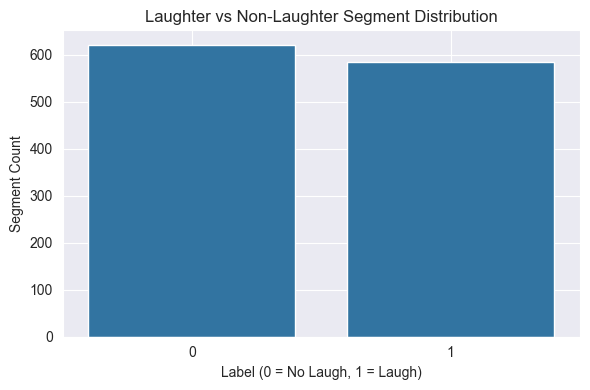

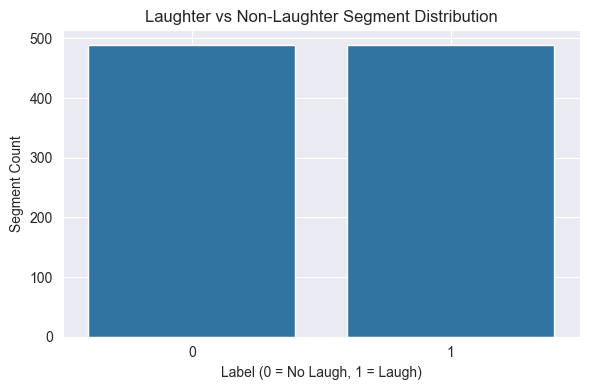

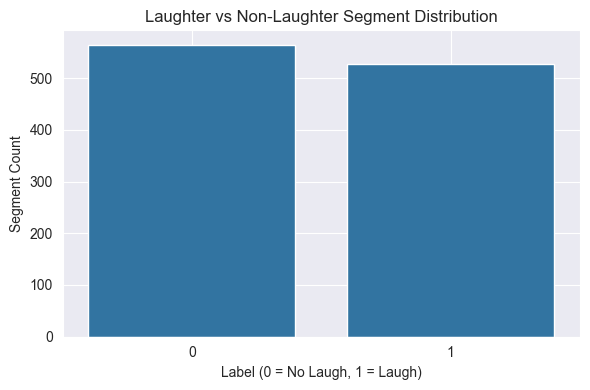

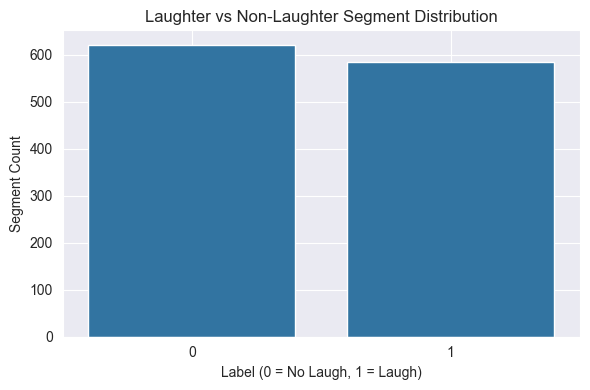

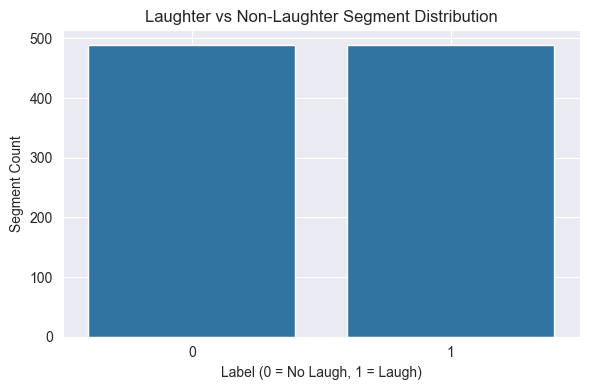

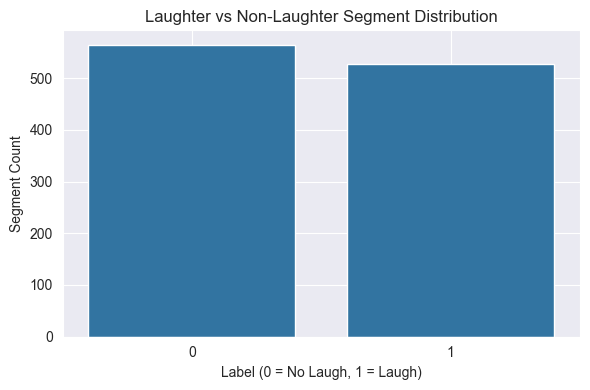

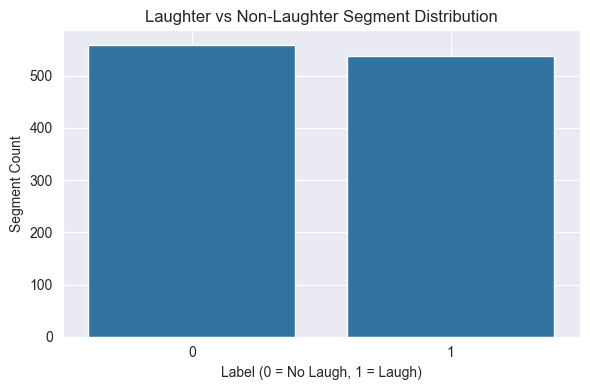

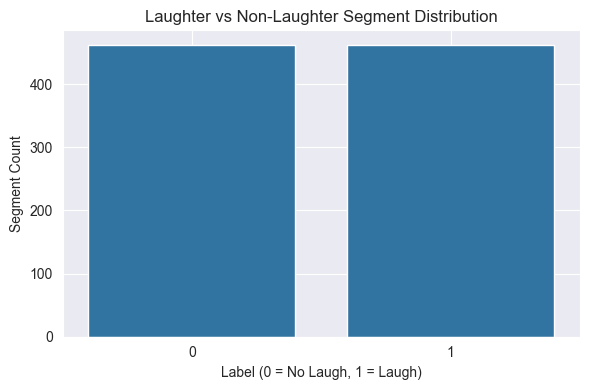

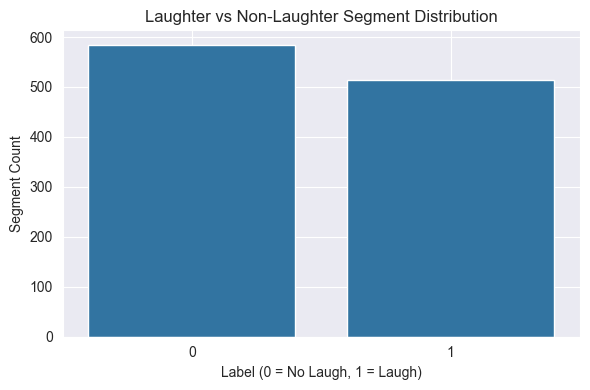

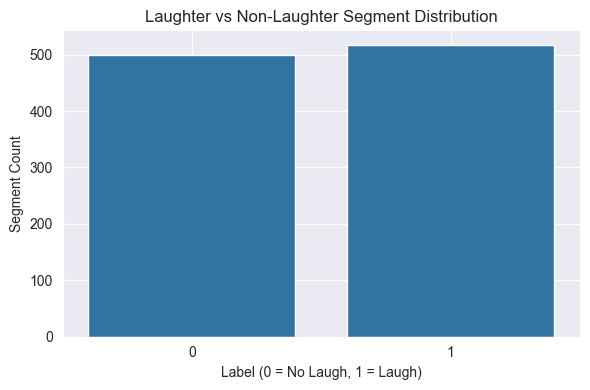

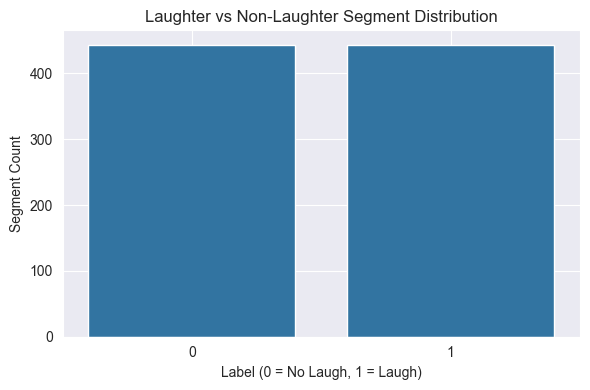

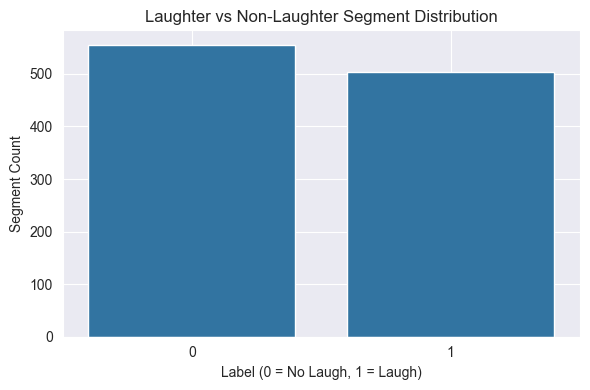

In [17]:
print_statistics(sna_three_twelve  )
print_statistics(swa_three_twelve  )
print_statistics(sao_three_twelve  )

print_statistics(sna_one_twelve)
print_statistics(swa_one_twelve)
print_statistics(sao_one_twelve)

print_statistics(sna_five_twelve)
print_statistics(swa_five_twelve)
print_statistics(sao_five_twelve)

print_statistics(sna_ten_twelve)
print_statistics(swa_ten_twelve)
print_statistics(sao_ten_twelve)

In [21]:
#upload dfs to files
pd.DataFrame(sna_three_twelve  ).to_csv("data_final_experiment/gap/maj/sna_three_twelve_gap.csv", index=False)
pd.DataFrame(swa_three_twelve  ).to_csv("data_final_experiment/gap/maj/swa_three_twelve_gap.csv", index=False)
pd.DataFrame(sao_three_twelve  ).to_csv("data_final_experiment/gap/maj/sao_three_twelve_gap.csv", index=False)

pd.DataFrame(sna_one_twelve).to_csv("data_final_experiment/gap/maj/sna_quarter_twelve_gap.csv", index=False)
pd.DataFrame(swa_one_twelve).to_csv("data_final_experiment/gap/maj/swa_quarter_twelve_gap.csv", index=False)
pd.DataFrame(sao_one_twelve).to_csv("data_final_experiment/gap/maj/sao_quarter_twelve_gap.csv", index=False)
#
pd.DataFrame(sna_five_twelve ).to_csv("data_final_experiment/gap/maj/sna_five_twelve_gap.csv", index=False)
pd.DataFrame(swa_five_twelve ).to_csv("data_final_experiment/gap/maj/swa_five_twelve_gap.csv", index=False)
pd.DataFrame(sao_five_twelve ).to_csv("data_final_experiment/gap/maj/sao_five_twelve_gap.csv", index=False)

pd.DataFrame(sna_ten_twelve).to_csv("data_final_experiment/gap/maj/sna_ten_twelve_gap.csv", index=False)
pd.DataFrame(swa_ten_twelve).to_csv("data_final_experiment/gap/maj/swa_ten_twelve_gap.csv", index=False)
pd.DataFrame(sao_ten_twelve).to_csv("data_final_experiment/gap/maj/sao_ten_twelve_gap.csv", index=False)



In [22]:
df_majority.to_csv("csvs/df_majority.csv", index = False)


Processing video vid2_seg8
agent 0


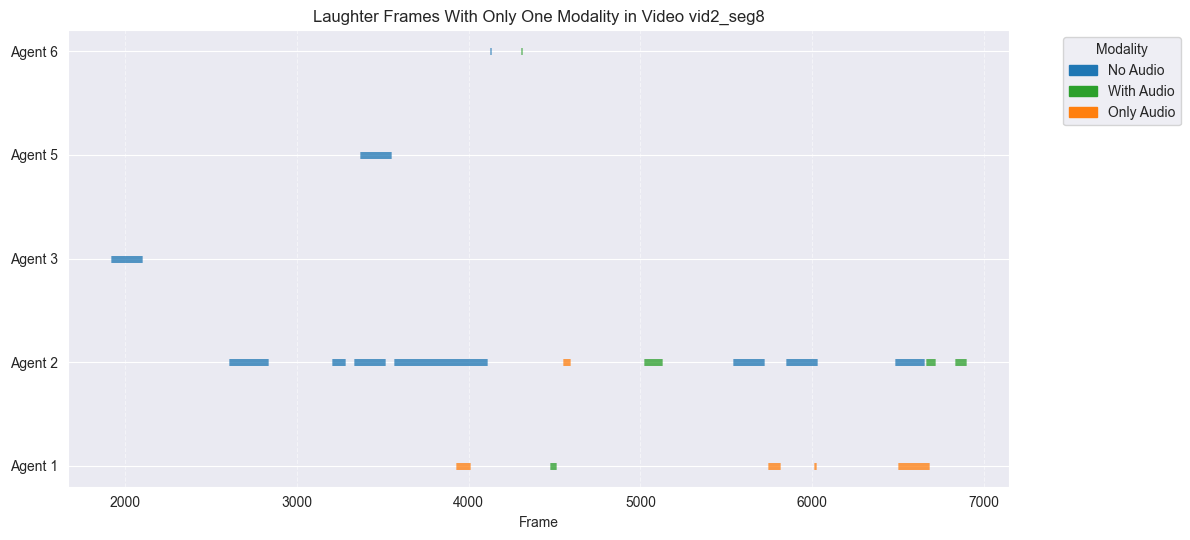

agent 0


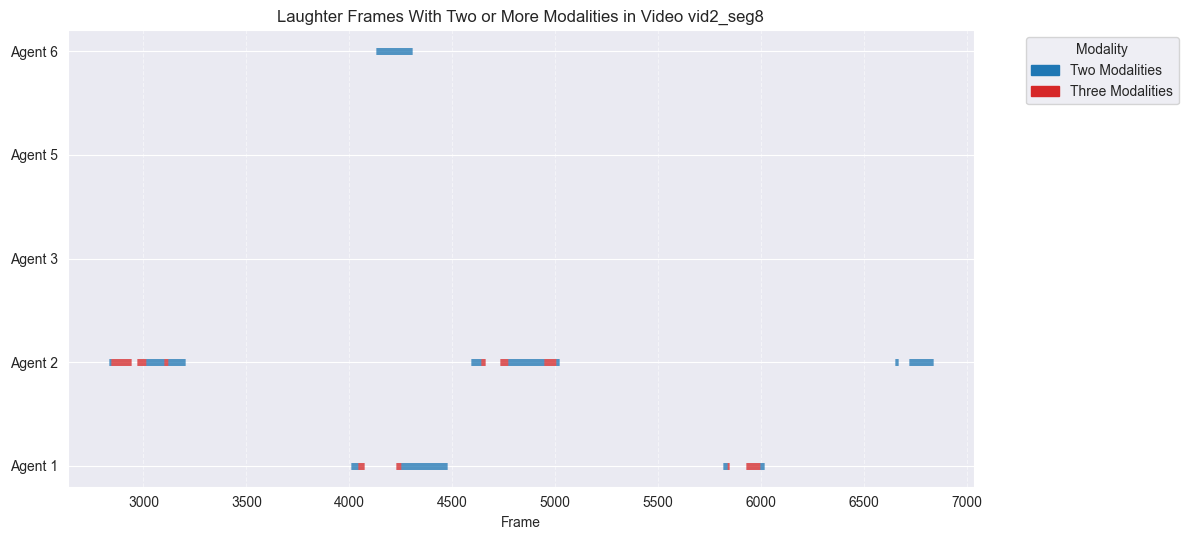

Processing video vid3_seg1
agent 0


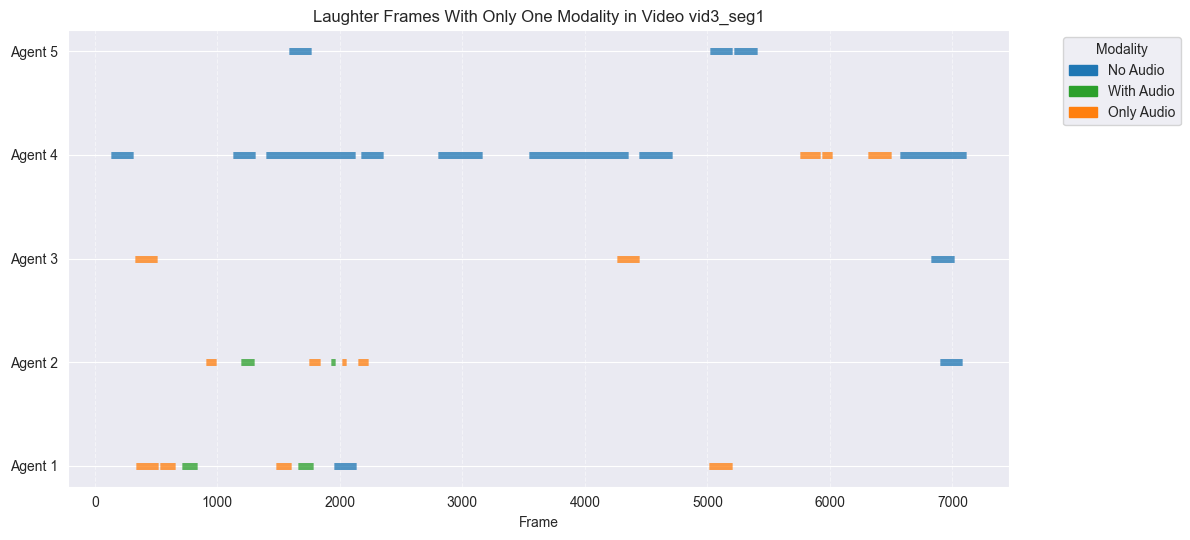

agent 0


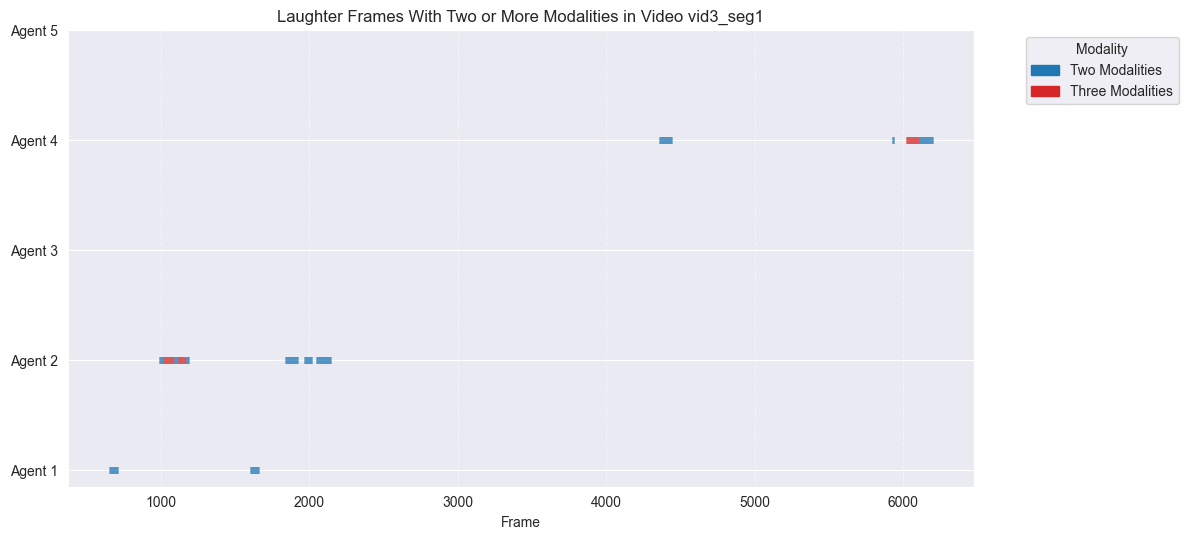

Processing video vid3_seg3
agent 0


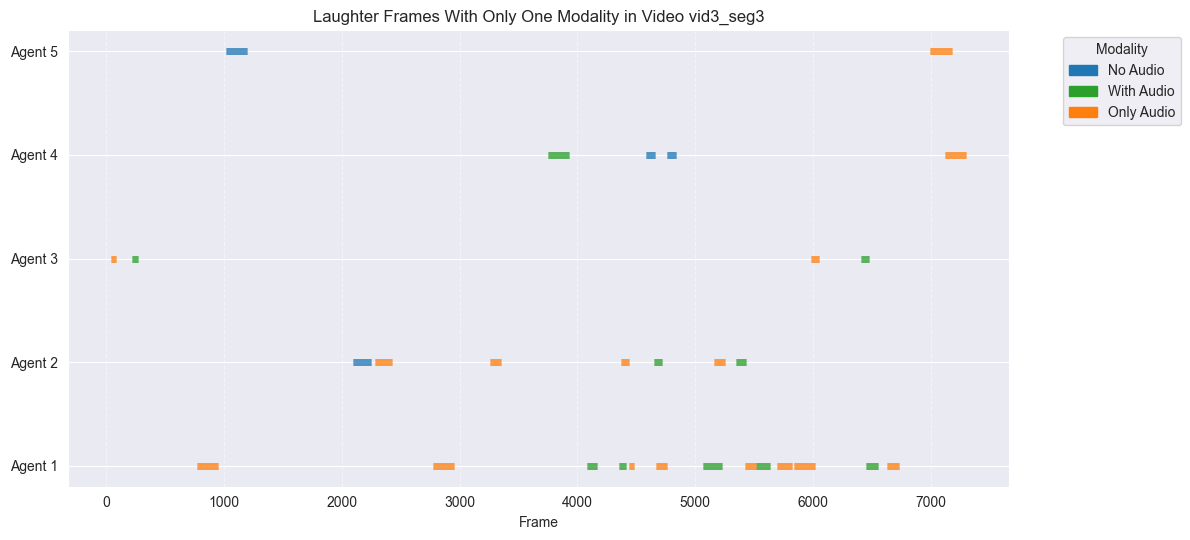

agent 0


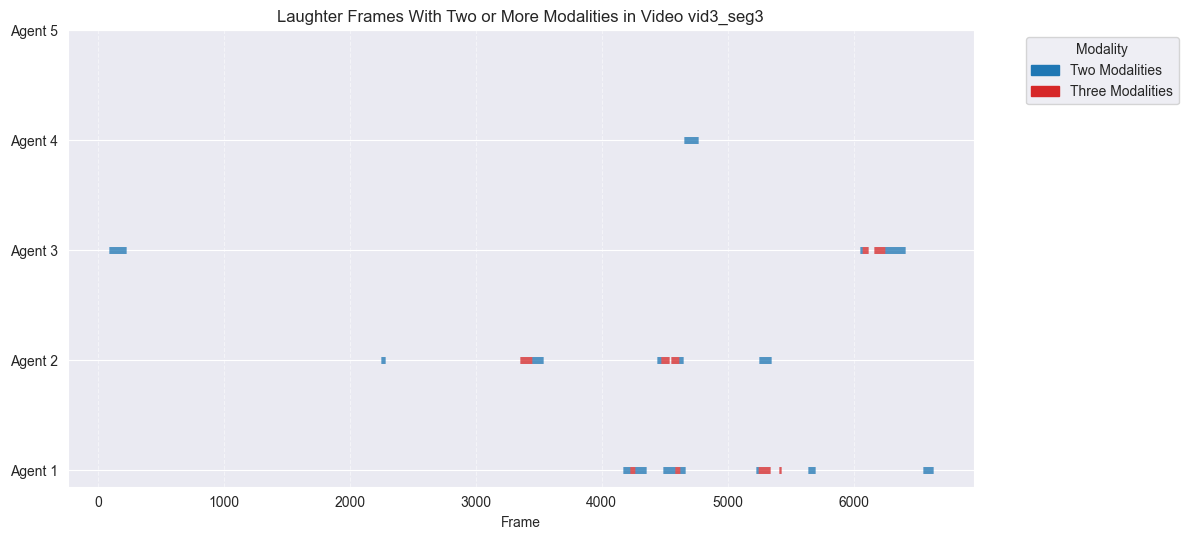

Processing video vid3_seg4
agent 0


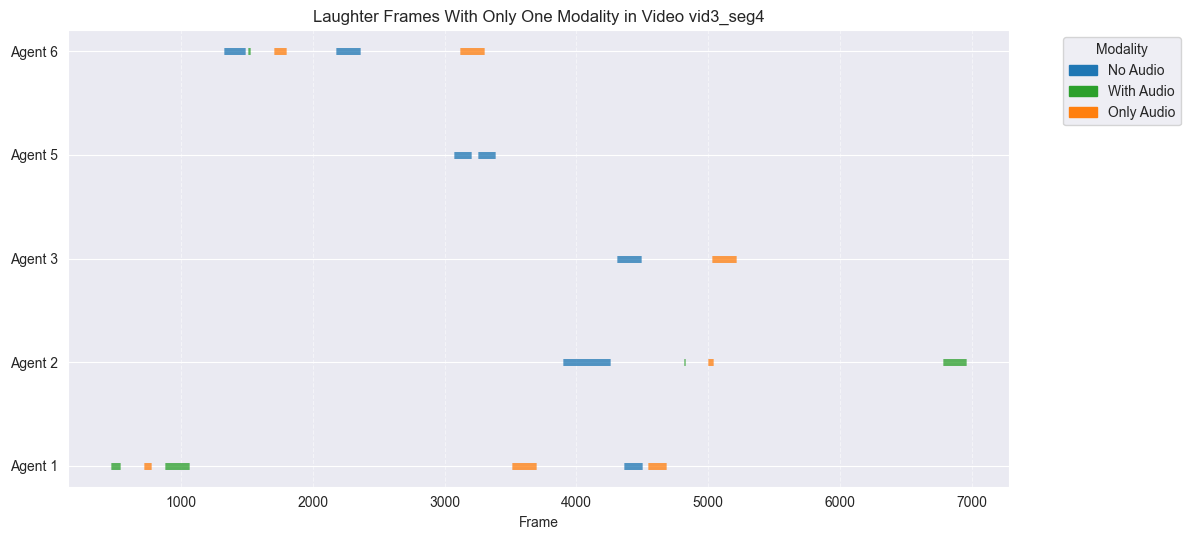

agent 0


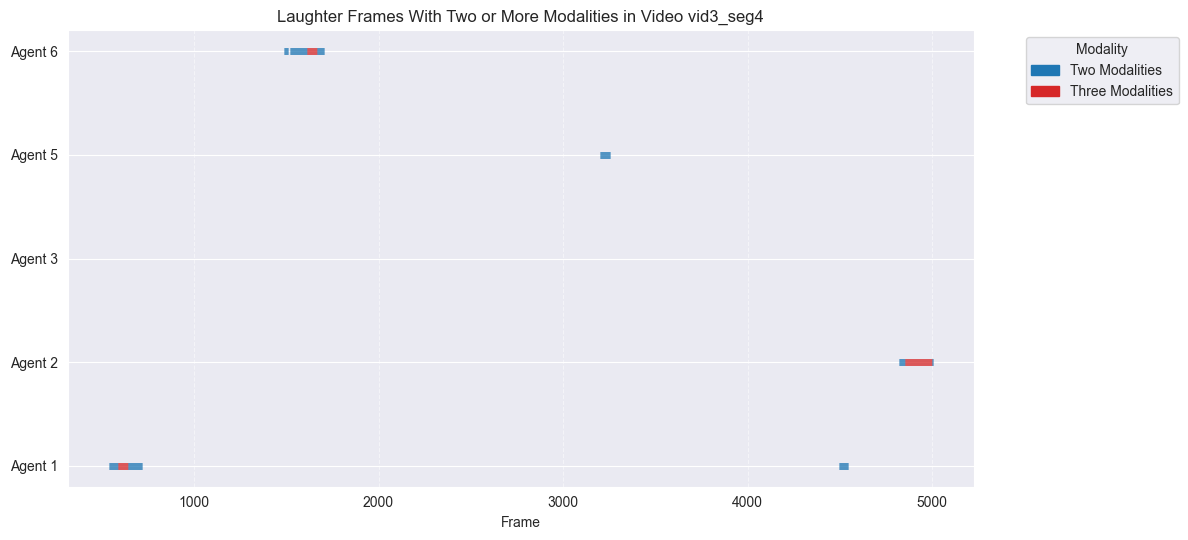

Processing video vid2_seg9
agent 0


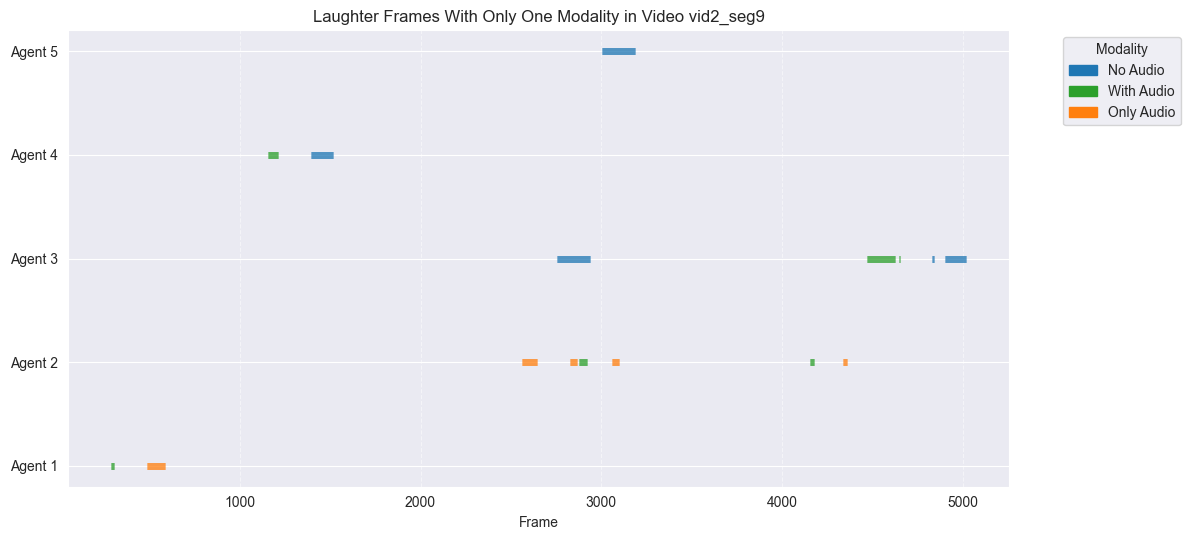

agent 0


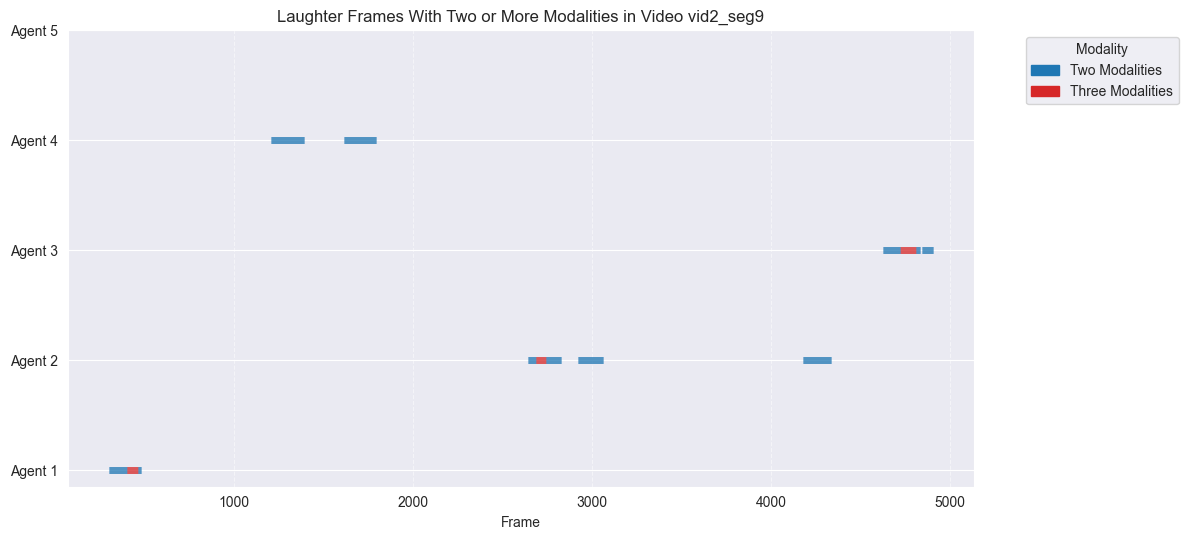

Processing video vid3_seg5
agent 0


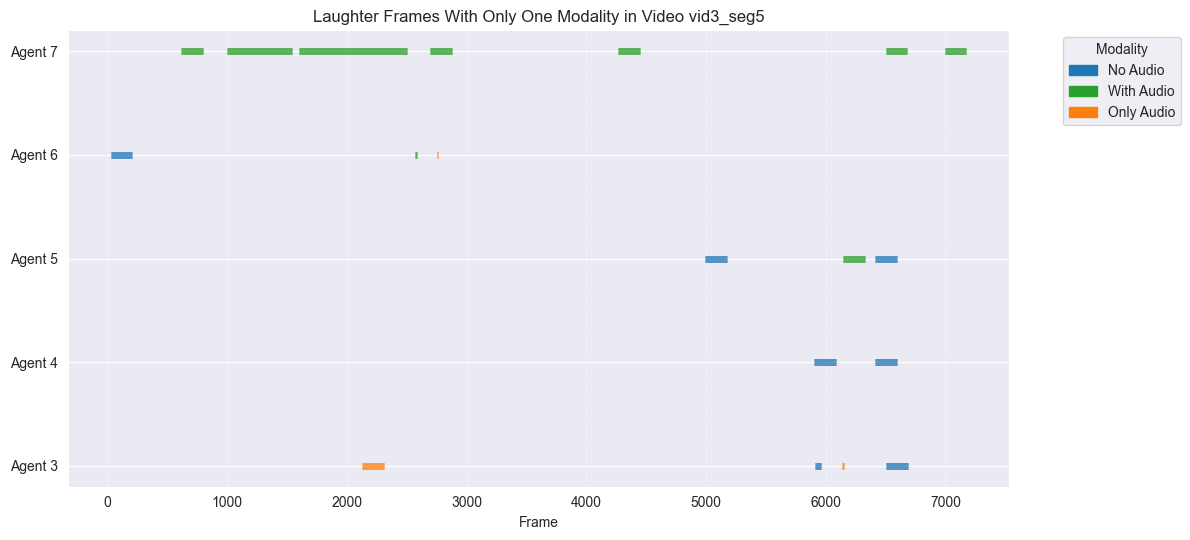

agent 0


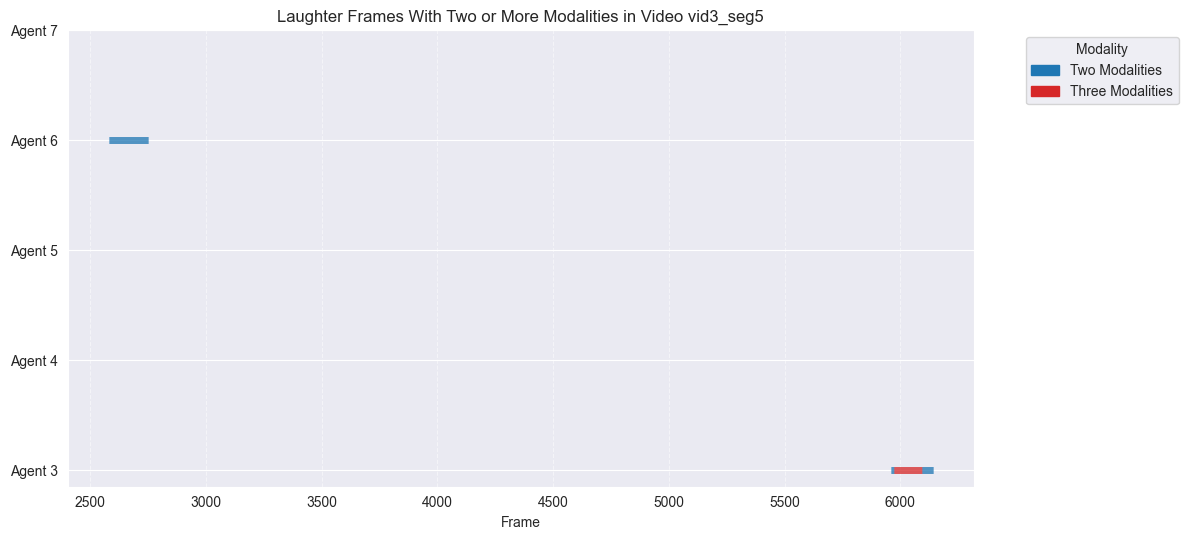

Processing video vid3_seg6
agent 0


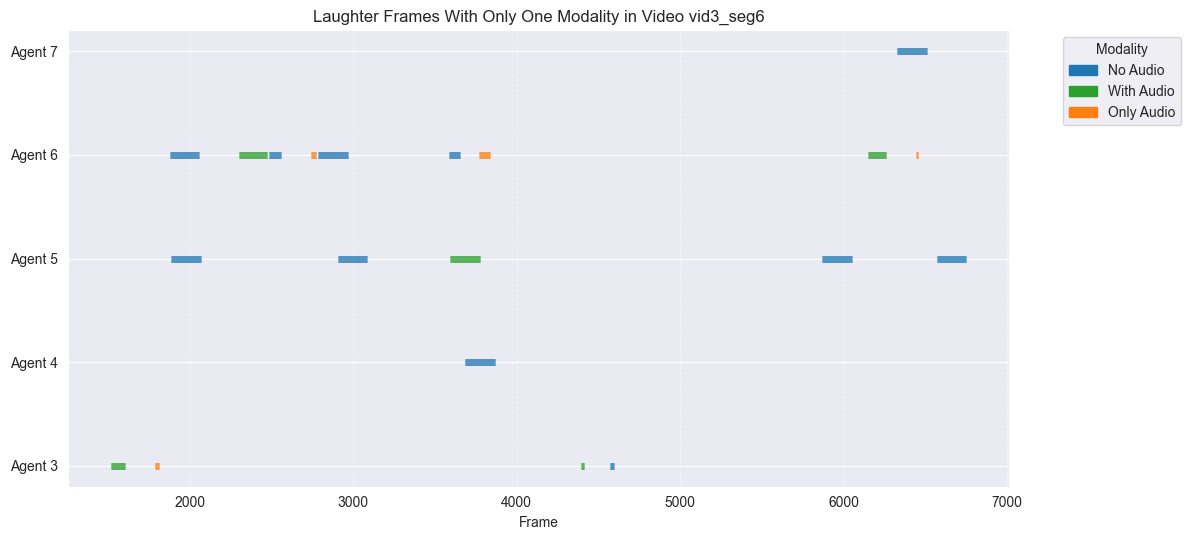

agent 0


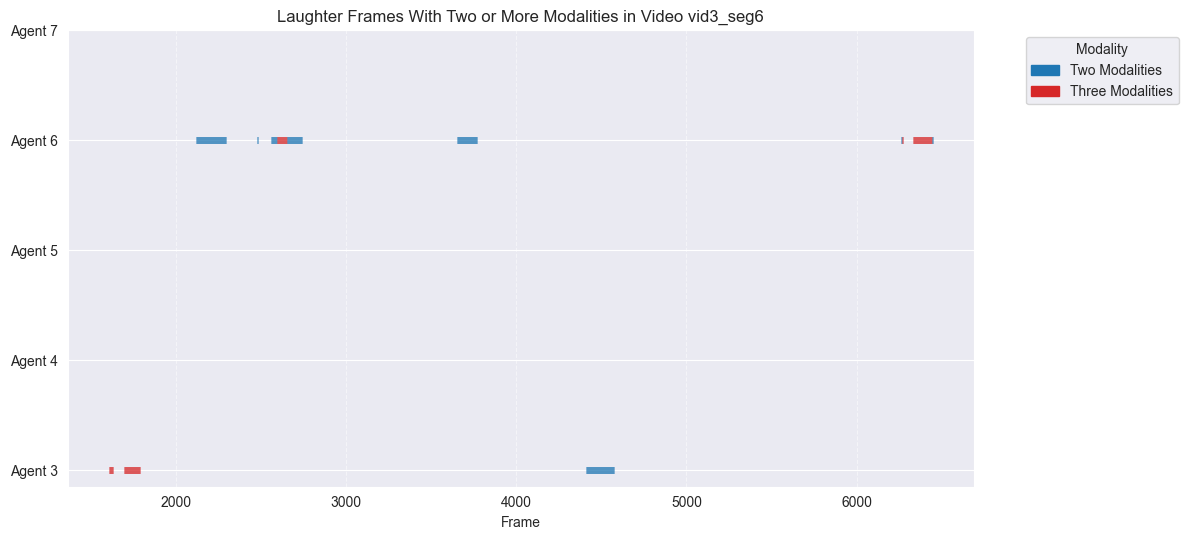

Processing video vid3_seg2
agent 0


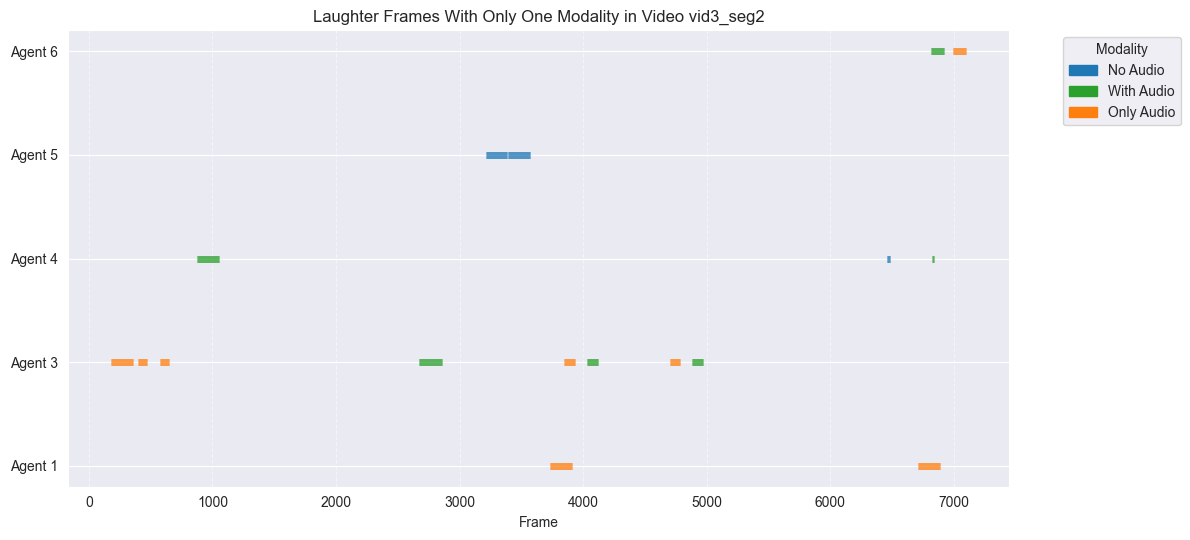

agent 0


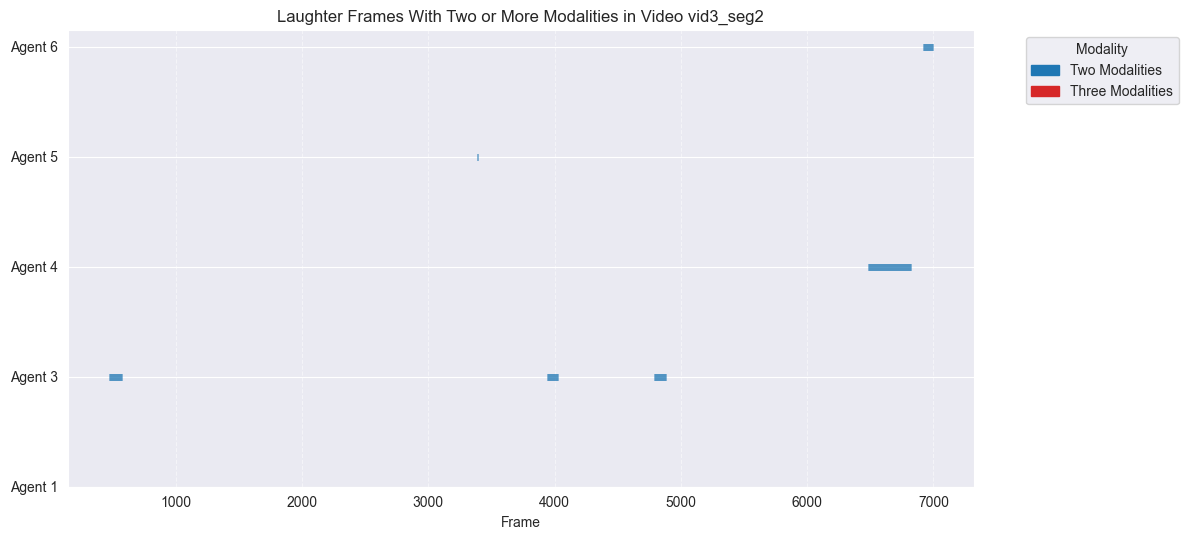

In [24]:
# Define color mappings for modalities
modality_map = {
    'No Audio': 'tab:blue',
    'With Audio': 'tab:green',
    'Only Audio': 'tab:orange'
}

# Define color mappings for agreement cases
agreement_map = {
    'Two Modalities': 'tab:blue',
    'Three Modalities': 'tab:red',
}

# Assign human-readable modality labels
fsna = sna_three_twelve  # No Audio
fswa = swa_three_twelve  # With Audio
fsao = sao_three_twelve  # Only Audio

# Add modality labels as a column
fsna['modality'] = 'No Audio'
fswa['modality'] = 'With Audio'
fsao['modality'] = 'Only Audio'

# Merge all modality dataframes into one long-format DataFrame
all_df = pd.concat([fsna, fswa, fsao], ignore_index=True)

# Keep only positive-labeled (i.e., laughter) segments
positive_df = all_df[all_df['label'] == 1]

# Get list of unique videos containing laughter
video_ids = positive_df['video_id'].unique()

# Limit plotting to max 2 videos
for y, vid in enumerate(video_ids):
    print(f"Processing video {vid}")

    pos_vid_df = positive_df[positive_df['video_id'] == vid]  # Filter data for current video
    agents = sorted(pos_vid_df['agent_id'].unique())[:5]      # Limit to first 5 agents

    # Get global frame bounds for plotting
    min_frame = pos_vid_df['start_frame'].min()
    max_frame = pos_vid_df['end_frame'].max()

    # Plot two types of visualizations
    for plot_type in ["exclusive", "agreement"]:
        if plot_type == "exclusive":
            min_required = 1
            max_required = 1
            title = "Frames With Only One Modality"
        else:
            min_required = 2
            max_required = 3
            title = "Frames With Two or More Modalities"

        # Create horizontal timeline plot
        plt.figure(figsize=(12, 0.5 + len(agents)))
        plt.title(f"Laughter {title} in Video {vid}")
        plt.xlabel("Frame")
        yticks = []

        for i, agent in enumerate(agents):
            if i % 5 == 0:
                print(f"agent {i}")

            yticks.append(f"Agent {agent}")
            agent_df = pos_vid_df[pos_vid_df['agent_id'] == agent]

            # Build a per-frame list of modalities where laughter is detected
            frame_mod_map = {}

            for _, row in agent_df.iterrows():
                for frame in range(row['start_frame'], row['end_frame'] + 1):
                    if frame not in frame_mod_map:
                        frame_mod_map[frame] = []
                    frame_mod_map[frame].append(row['modality'])

            # Draw colored lines based on how many modalities agree on laughter
            for frame, modalities in frame_mod_map.items():
                l = len(modalities)
                if min_required <= l <= max_required:
                    if l == 3:
                        color = agreement_map['Three Modalities']
                    elif l == 2:
                        color = agreement_map['Two Modalities']
                    else:
                        color = modality_map[modalities[0]]  # Single-modality frame
                    plt.hlines(y=i, xmin=frame, xmax=frame+1, colors=color, linewidth=5)

        # Set y-axis to show agent IDs
        plt.yticks(range(len(agents)), yticks)
        plt.grid(True, axis='x', linestyle='--', alpha=0.5)

        # Draw legend
        legend_map = modality_map if plot_type == "exclusive" else agreement_map
        patches = [mpatches.Patch(color=color, label=label) for label, color in legend_map.items()]
        plt.legend(handles=patches, title="Modality", bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()


In [25]:
cols = ['is_laughing_with_audio', 'is_laughing_only_audio', 'is_laughing_no_audio']

# Count how many 1s are in each row for the specified columns
df_majority['sum_ones'] = df_majority[cols].sum(axis=1)

# Filter out rows with all 0s
filtered = df_majority[df_majority['sum_ones'] > 0]

# Count how many rows have 1, 2, or 3 ones
agreement_counts = filtered['sum_ones'].value_counts().sort_index()

# Calculate percentages
total = agreement_counts.sum()
agreement_percentages = (agreement_counts / total * 100).round(2)

# Combine into a summary DataFrame
summary_df = pd.DataFrame({
    'count': agreement_counts,
    'percentage': agreement_percentages
})

print(summary_df)

          count  percentage
sum_ones                   
1.0       71532       83.46
2.0       12206       14.24
3.0        1969        2.30
